# Architecture of filters

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [5]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution

In [3]:
doc = fitz.open('Diaz-Perez_Rodriguez_2006_One Dimensional Cyclic Convolution Algorithms with Minimal Multiplicative.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

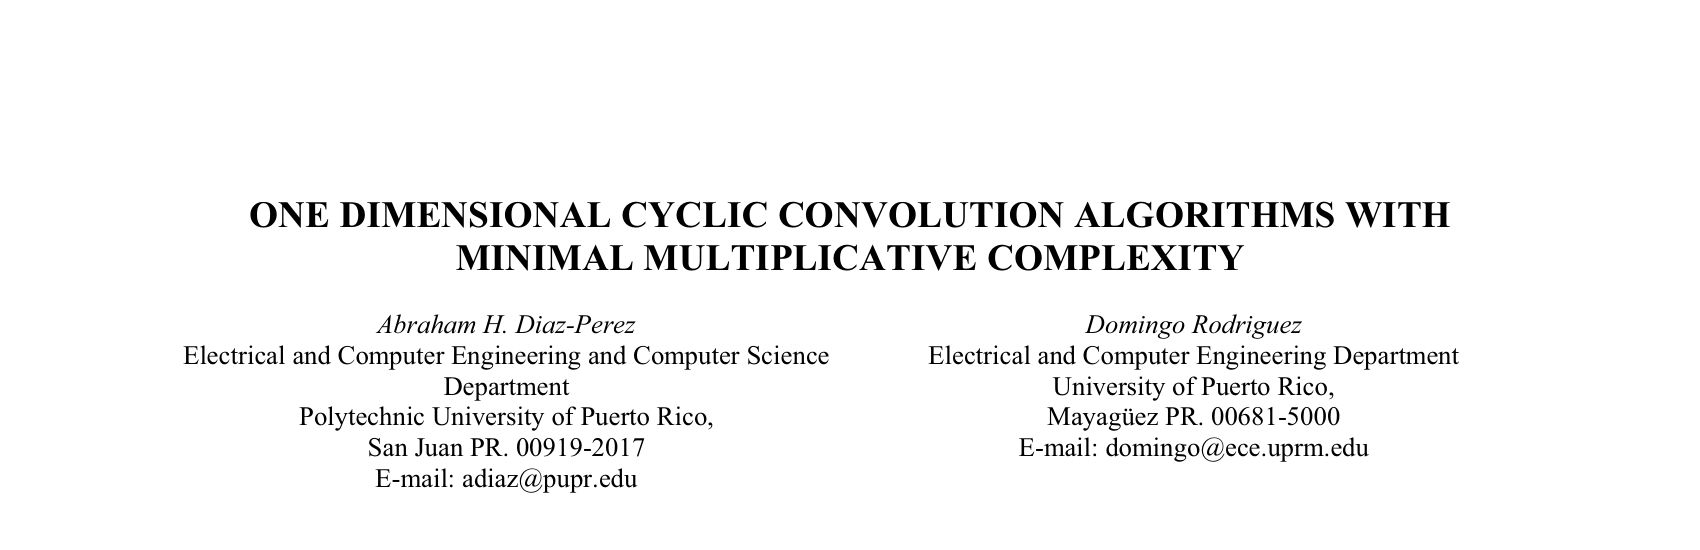

In [10]:
plot_pdf(doc[0], (0, .25))

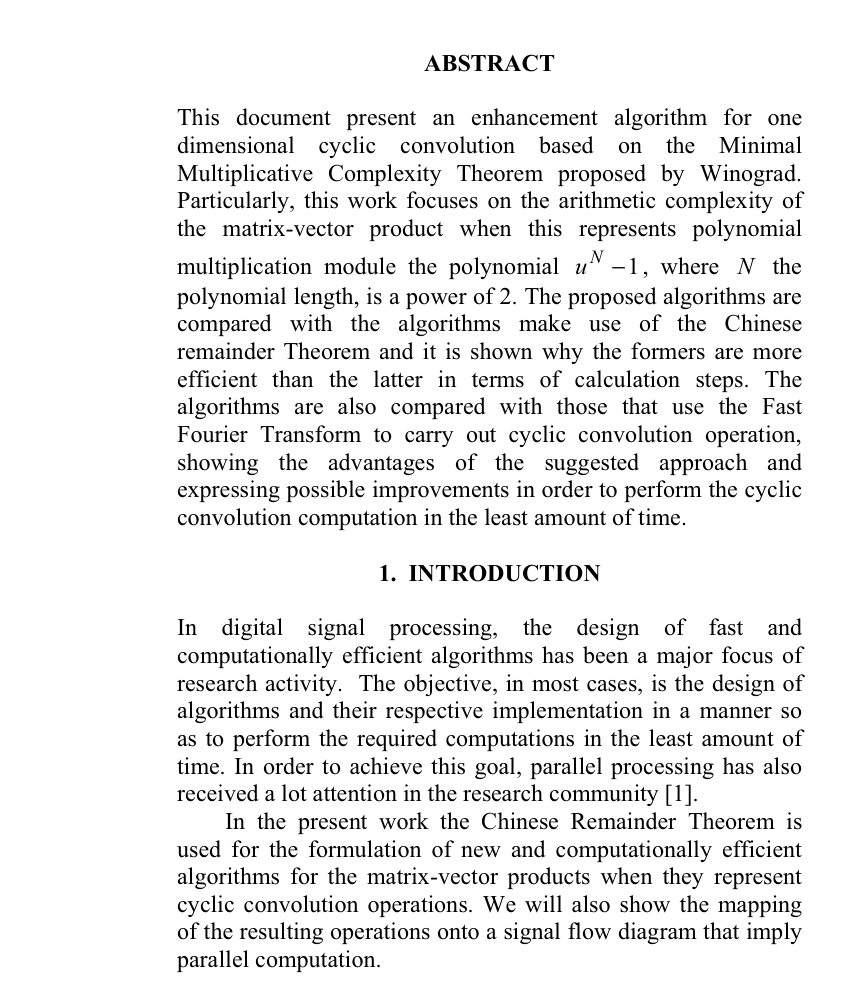

In [16]:
plot_pdf2col(doc[0], 0, [.23, .68])

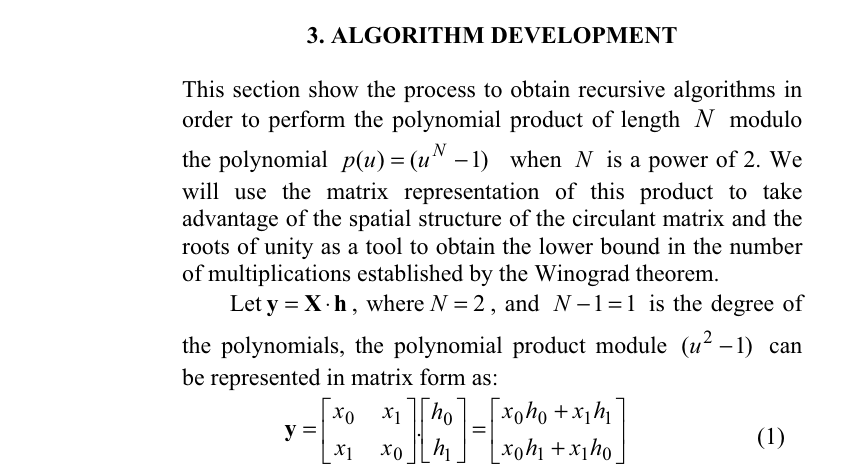

In [24]:
plot_pdf2col(doc[1], 0, [.465, .68])

Size of vectors

In [26]:
x_num = 2
h_num = 2

Example of vectors for the convolution

In [30]:
x_values = list(range(1, x_num+1))
h_values = list(range(1, x_num+1))
print(x_values, h_values)

[1, 2] [1, 2]


Polynomial degree

In [31]:
x_degree = x_num - 1
h_degree = x_num - 1
print(x_degree, h_degree)

1 1


In [85]:
z = sy.symbols("z")
z

z

In [86]:
x = sy.Matrix(sy.symbols(" ".join(f"x_{i}"for i in range(x_num))))
x

Matrix([
[x_0],
[x_1]])

In [87]:
h = sy.Matrix(sy.symbols(" ".join(f"h_{i}"for i in range(h_num))))
h

Matrix([
[h_0],
[h_1]])

In [88]:
xz = sum([i*z**e for e, i in enumerate(x)])
xz

x_0 + x_1*z

In [89]:
hz = sum([i*z**e for e, i in enumerate(h)])
hz

h_0 + h_1*z

In [40]:
yz = xz*hz
yz

(h_0 + h_1*z)*(x_0 + x_1*z)

In [53]:
mx = sy.Matrix([
    [x[0], x[1]],
    [x[1], x[0]],
])
mx

Matrix([
[x_0, x_1],
[x_1, x_0]])

In [54]:
mx*h

Matrix([
[h_0*x_0 + h_1*x_1],
[h_0*x_1 + h_1*x_0]])

In [59]:
sy.Matrix(symmetrical_cyclic_convolution(np.array(x).reshape(-1), np.array(h).reshape(-1)))

Matrix([
[h_0*x_0 + h_1*x_1],
[h_0*x_1 + h_1*x_0]])

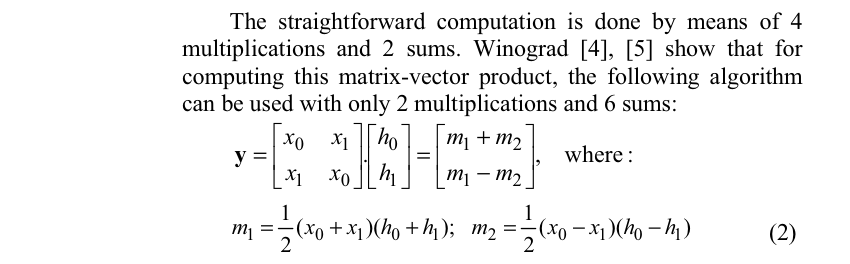

In [55]:
plot_pdf2col(doc[1], 0, [.68, .8])

Just defining values of matrices

In [56]:
m_winog = sy.Matrix([[1, 1], [1, -1]])
m_winog

Matrix([
[1,  1],
[1, -1]])

In [57]:
bg_mtx = sy.diag(*(m_winog*x*1/2).tolist())
bg_mtx

Matrix([
[x_0/2 + x_1/2,             0],
[            0, x_0/2 - x_1/2]])

In [60]:
se = sy.MatMul(m_winog * bg_mtx * m_winog, h)
se

Matrix([
[x_0, x_1],
[x_1, x_0]])*Matrix([
[h_0],
[h_1]])

In [62]:
sy.MatMul(m_winog, bg_mtx, m_winog, h, evaluate=True)

Matrix([
[h_0*x_0 + h_1*x_1],
[h_0*x_1 + h_1*x_0]])

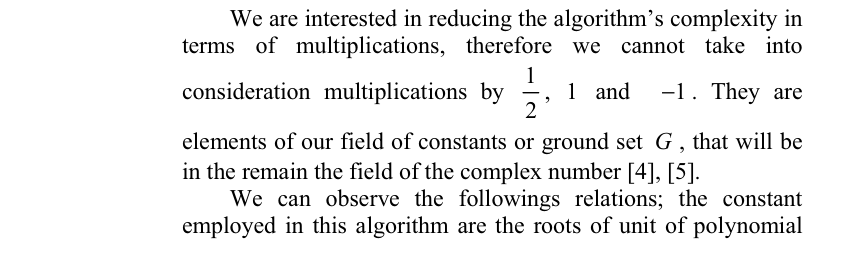

In [68]:
plot_pdf2col(doc[1], 0, [.8, .92])

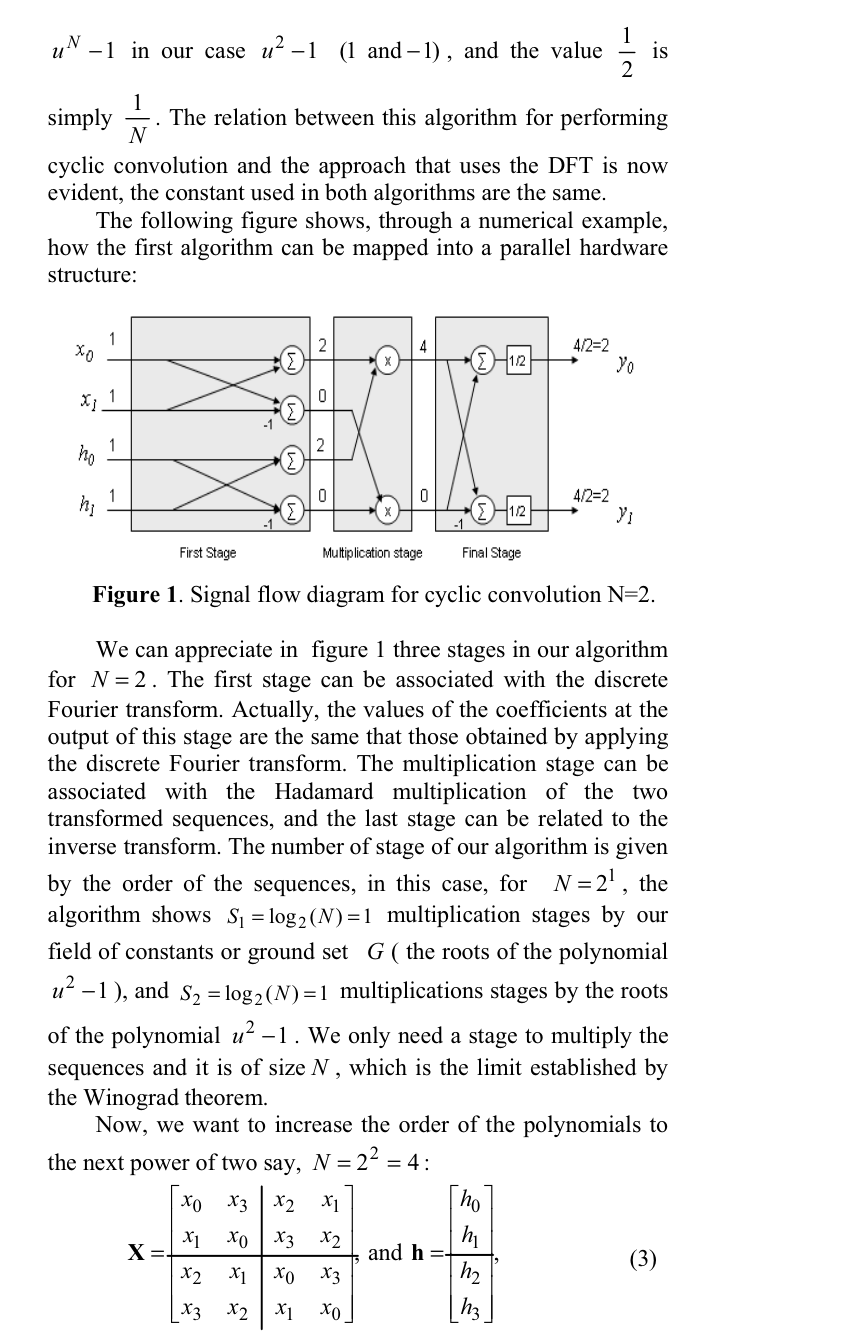

In [80]:
plot_pdf2col(doc[1], 1, [0.08, .69])

In [83]:
xx = sy.Matrix(sy.symbols(" ".join(f"x_{i}"for i in range(x_num*2))))
x

Matrix([
[x_0],
[x_1],
[x_2],
[x_3]])

In [84]:
hh = sy.Matrix(sy.symbols(" ".join(f"h_{i}"for i in range(h_num*2))))
hh

Matrix([
[h_0],
[h_1],
[h_2],
[h_3]])

In [91]:
cc4 = sy.Matrix(symmetrical_cyclic_convolution(np.array(xx).reshape(-1), np.array(hh).reshape(-1)))
cc4

Matrix([
[h_0*x_0 + h_1*x_3 + h_2*x_2 + h_3*x_1],
[h_0*x_1 + h_1*x_0 + h_2*x_3 + h_3*x_2],
[h_0*x_2 + h_1*x_1 + h_2*x_0 + h_3*x_3],
[h_0*x_3 + h_1*x_2 + h_2*x_1 + h_3*x_0]])

In [100]:
'h' in cc4[0].args[0].args[0].name

True

In [105]:
cc4_x_args = [[arg  for mul in line.args for arg in mul.args if 'x' in arg.name] for line in cc4]
cc4_x_args

[[x_0, x_3, x_2, x_1],
 [x_1, x_0, x_3, x_2],
 [x_2, x_1, x_0, x_3],
 [x_3, x_2, x_1, x_0]]

In [109]:
cc4_x_args[0:2][0][0:2]

[x_0, x_3]

In [110]:
cc4_x_args[0:2][1][0:2]

[x_1, x_0]

In [111]:
mxx = [None, None]

In [115]:
mxx[0] = sy.Matrix(np.array(cc4_x_args)[0:2, 0:2])
mxx[0]

Matrix([
[x_0, x_3],
[x_1, x_0]])

In [116]:
mxx[1] = sy.Matrix(np.array(cc4_x_args)[2:4, 0:2])
mxx[1]

Matrix([
[x_2, x_1],
[x_3, x_2]])

In [24]:
si = sy.Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(4))))
si

Matrix([
[s_0],
[s_1],
[s_2],
[s_3]])

In [25]:
ddi = sy.Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(2))))
ddi

Matrix([
[D_0],
[D_1]])

In [26]:
ggi = sy.Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(2))))
ggi

Matrix([
[G_0],
[G_1]])

In [27]:
ssi = sy.Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(1, 3))))
ssi

Matrix([
[S_1],
[S_2]])

In [28]:
gg = [None for n in range(2)]

In [29]:
gg[0] = sy.Matrix([
    [gi[0], gi[3]],
    [gi[1], gi[0]]
])
gg[0]

Matrix([
[g_0, g_3],
[g_1, g_0]])

In [30]:
gg[1] = sy.Matrix([
    [gi[2], gi[1]],
    [gi[3], gi[2]]
])
gg[1]

Matrix([
[g_2, g_1],
[g_3, g_2]])

In [31]:
dd = [None for n in range(2)]
dd

[None, None]

In [32]:
dd[0] = sy.Matrix([di[0], di[1]])
dd[0]

Matrix([
[d_0],
[d_1]])

In [33]:
dd[1] = sy.Matrix([di[2], di[3]])
dd[1]

Matrix([
[d_2],
[d_3]])

In [34]:
ii = sy.symbols('I')
ii

I

In [35]:
dd_mtx = sy.Matrix([
    [ii, ii], 
    [ii, -ii]
])
dd_mtx

Matrix([
[I,  I],
[I, -I]])

In [36]:
gg_mtx = sy.diag(*[
    ggi[0] + ggi[1], 
    ggi[0]- ggi[1]
])* 1/2
gg_mtx

Matrix([
[G_0/2 + G_1/2,             0],
[            0, G_0/2 - G_1/2]])

In [37]:
cc_mtx = sy.Matrix([
    [ii, ii], 
    [ii, -ii]
])
cc_mtx

Matrix([
[I,  I],
[I, -I]])

In [38]:
sy.MatMul(cc_mtx, gg_mtx, dd_mtx, ddi)

Matrix([
[I,  I],
[I, -I]])*Matrix([
[G_0/2 + G_1/2,             0],
[            0, G_0/2 - G_1/2]])*Matrix([
[I,  I],
[I, -I]])*Matrix([
[D_0],
[D_1]])

In [39]:
cc_mtx = sy.Matrix([
    [sy.eye(2), sy.eye(2)], 
    [sy.eye(2), -sy.eye(2)]
])
cc_mtx

Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])

In [40]:
dd_mtx = sy.Matrix([
    [sy.eye(2), sy.eye(2)], 
    [sy.eye(2), -sy.eye(2)]
])
dd_mtx

Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])

In [41]:
gg_mtx = sy.diag(*[
    gg[0] + gg[1], 
    gg[0] - gg[1]
])* 1/2
gg_mtx

Matrix([
[g_0/2 + g_2/2, g_1/2 + g_3/2,             0,              0],
[g_1/2 + g_3/2, g_0/2 + g_2/2,             0,              0],
[            0,             0, g_0/2 - g_2/2, -g_1/2 + g_3/2],
[            0,             0, g_1/2 - g_3/2,  g_0/2 - g_2/2]])

In [42]:
gg_mtx.shape

(4, 4)

In [43]:
sy.Matrix(symmetrical_cyclic_convolution(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[d_0*g_0 + d_1*g_3 + d_2*g_2 + d_3*g_1],
[d_0*g_1 + d_1*g_0 + d_2*g_3 + d_3*g_2],
[d_0*g_2 + d_1*g_1 + d_2*g_0 + d_3*g_3],
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0]])

In [44]:
ssx = sy.MatMul(cc_mtx, gg_mtx, dd_mtx, di, evaluate=True)
ssx

Matrix([
[d_0*g_0 + d_1*g_3 + d_2*g_2 + d_3*g_1],
[d_0*g_1 + d_1*g_0 + d_2*g_3 + d_3*g_2],
[d_0*g_2 + d_1*g_1 + d_2*g_0 + d_3*g_3],
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0]])

In [45]:
ssx = sy.MatMul(cc_mtx, gg_mtx, dd_mtx, di)
ssx

Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])*Matrix([
[g_0/2 + g_2/2, g_1/2 + g_3/2,             0,              0],
[g_1/2 + g_3/2, g_0/2 + g_2/2,             0,              0],
[            0,             0, g_0/2 - g_2/2, -g_1/2 + g_3/2],
[            0,             0, g_1/2 - g_3/2,  g_0/2 - g_2/2]])*Matrix([
[1, 0,  1,  0],
[0, 1,  0,  1],
[1, 0, -1,  0],
[0, 1,  0, -1]])*Matrix([
[d_0],
[d_1],
[d_2],
[d_3]])

In [46]:
subs = {k: v for k, v in zip(gi.flat(), range(0, len(gi.flat())))}
subs

{g_0: 0, g_1: 1, g_2: 2, g_3: 3}

In [47]:
gg_mtx_subs = gg_mtx.subs(subs)
gg_mtx_subs

Matrix([
[1, 2,  0,  0],
[2, 1,  0,  0],
[0, 0, -1,  1],
[0, 0, -1, -1]])

In [48]:
sy.Matrix(symmetrical_cyclic_convolution(range(len(di.flat())), range(len(gi.flat()))))

Matrix([
[10],
[12],
[10],
[ 4]])

In [49]:
r = cc_mtx * gg_mtx_subs * dd_mtx * sy.Matrix([0, 1, 2, 3])
r

Matrix([
[10],
[12],
[10],
[ 4]])